# 📧 Email Spam Detection
### Oasis Infobyte Data Science Internship — Task 4
**Name:** Sadiya Anmol  
**Track:** Data Science  
**Dataset:** SMS Spam Collection (Kaggle)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, 
                             recall_score, f1_score,
                             confusion_matrix, classification_report)
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import string
import warnings
warnings.filterwarnings('ignore')

# Download NLTK data
nltk.download('stopwords')
nltk.download('punkt')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\anmol\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\anmol\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


## 1. Load Dataset & Initial Inspection

In [4]:
# Load dataset
df = pd.read_csv('Downloads/spam.csv', encoding='latin-1')

# Keep only relevant columns
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (5572, 2)

First 5 rows:


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## 2. Class Distribution Check

Class Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Percentage:
label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


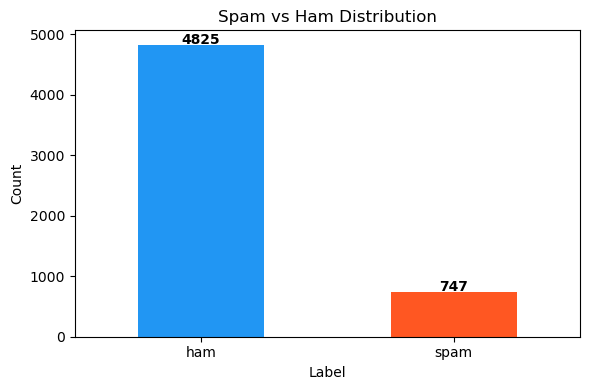

In [5]:
# Check spam vs ham counts
print("Class Distribution:")
print(df['label'].value_counts())
print("\nPercentage:")
print(df['label'].value_counts(normalize=True)*100)

# Visualize
import os
os.makedirs('screenshots', exist_ok=True)

plt.figure(figsize=(6,4))
colors = ['#2196F3', '#FF5722']
df['label'].value_counts().plot(kind='bar', color=colors)
plt.title('Spam vs Ham Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
for i, v in enumerate(df['label'].value_counts()):
    plt.text(i, v + 10, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('screenshots/distribution.png', bbox_inches='tight')
plt.show()

## 3. Text Preprocessing Pipeline
TF-IDF (Term Frequency-Inverse Document Frequency) measures 
how important a word is in a document relative to the corpus.
Words that appear frequently in one document but rarely across 
all documents get higher scores — helping identify spam-specific words.

In [6]:
ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Lowercase
    text = text.lower()
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Tokenize
    words = text.split()
    # Remove stopwords and stem
    words = [ps.stem(w) for w in words if w not in stop_words]
    return ' '.join(words)

# Apply preprocessing
df['cleaned_message'] = df['message'].apply(preprocess_text)

print("✅ Preprocessing done!")
print("\nOriginal:", df['message'][0])
print("Cleaned:", df['cleaned_message'][0])

✅ Preprocessing done!

Original: Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
Cleaned: go jurong point crazi avail bugi n great world la e buffet cine got amor wat


## 4. Feature Extraction using TF-IDF

In [7]:
# Convert labels to binary
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df['cleaned_message'])
y = df['label_num']

# Train test split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")
print(f"Features (TF-IDF): {X_train.shape[1]}")

Training samples: 4457
Testing samples: 1115
Features (TF-IDF): 3000


## 5. Model Training & Evaluation

In [8]:
# Train 3 models
models = {
    'Multinomial Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Support Vector Machine': SVC(kernel='linear')
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred)
    }
    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print(f"Accuracy:  {results[name]['Accuracy']*100:.2f}%")
    print(f"Precision: {results[name]['Precision']*100:.2f}%")
    print(f"Recall:    {results[name]['Recall']*100:.2f}%")
    print(f"F1 Score:  {results[name]['F1 Score']*100:.2f}%")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, 
          target_names=['Ham', 'Spam']))


Model: Multinomial Naive Bayes
Accuracy:  97.85%
Precision: 100.00%
Recall:    84.00%
F1 Score:  91.30%

Classification Report:
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       965
        Spam       1.00      0.84      0.91       150

    accuracy                           0.98      1115
   macro avg       0.99      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115


Model: Logistic Regression
Accuracy:  95.16%
Precision: 97.06%
Recall:    66.00%
F1 Score:  78.57%

Classification Report:
              precision    recall  f1-score   support

         Ham       0.95      1.00      0.97       965
        Spam       0.97      0.66      0.79       150

    accuracy                           0.95      1115
   macro avg       0.96      0.83      0.88      1115
weighted avg       0.95      0.95      0.95      1115


Model: Support Vector Machine
Accuracy:  98.12%
Precision: 98.50%
Recall:    87.33%
F1 Score

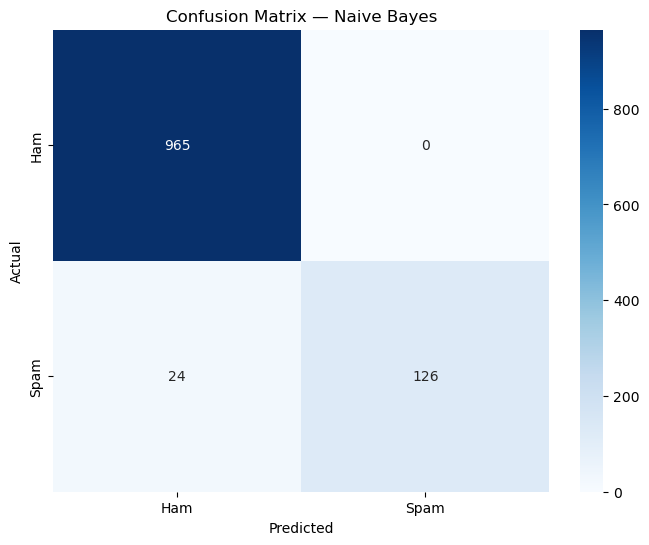

In [9]:
# Confusion matrix for best model
best_model = models['Multinomial Naive Bayes']
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])
plt.title('Confusion Matrix — Naive Bayes')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('screenshots/confusion_matrix.png', bbox_inches='tight')
plt.show()

<Figure size 1200x500 with 0 Axes>

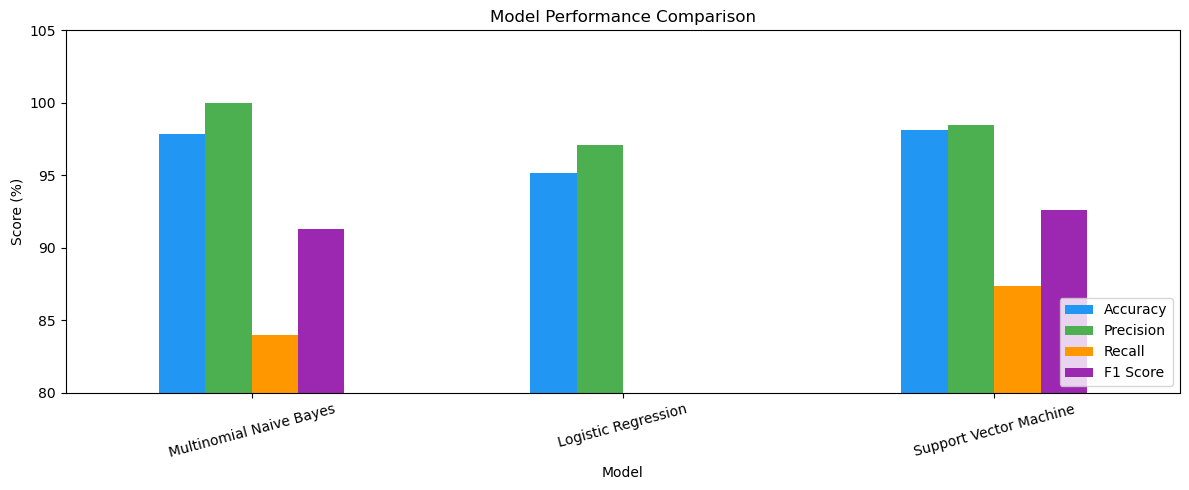

In [10]:
# Model comparison
results_df = pd.DataFrame(results).T * 100

plt.figure(figsize=(12,5))
results_df.plot(kind='bar', figsize=(12,5), 
                color=['#2196F3','#4CAF50','#FF9800','#9C27B0'])
plt.title('Model Performance Comparison')
plt.xlabel('Model')
plt.ylabel('Score (%)')
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.ylim(80, 105)
plt.tight_layout()
plt.savefig('screenshots/model_comparison.png', bbox_inches='tight')
plt.show()

In [12]:
pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


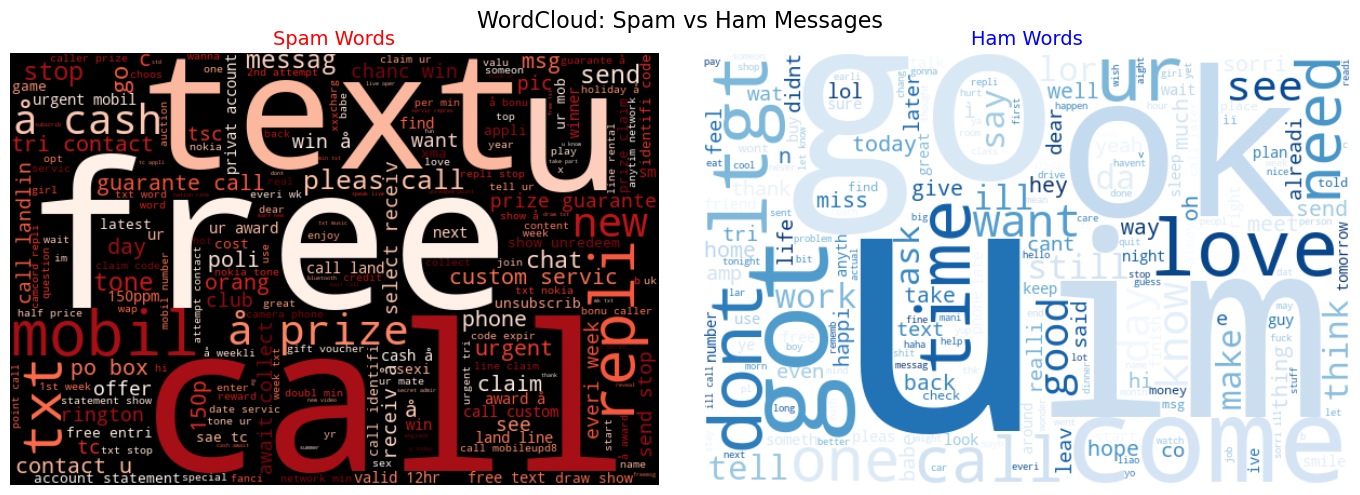

In [13]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Spam wordcloud
spam_text = ' '.join(df[df['label']=='spam']['cleaned_message'])
wc_spam = WordCloud(width=600, height=400, 
                    background_color='black',
                    colormap='Reds').generate(spam_text)
axes[0].imshow(wc_spam, interpolation='bilinear')
axes[0].set_title('Spam Words', fontsize=14, color='red')
axes[0].axis('off')

# Ham wordcloud
ham_text = ' '.join(df[df['label']=='ham']['cleaned_message'])
wc_ham = WordCloud(width=600, height=400,
                   background_color='white',
                   colormap='Blues').generate(ham_text)
axes[1].imshow(wc_ham, interpolation='bilinear')
axes[1].set_title('Ham Words', fontsize=14, color='blue')
axes[1].axis('off')

plt.suptitle('WordCloud: Spam vs Ham Messages', fontsize=16)
plt.tight_layout()
plt.savefig('screenshots/wordcloud.png', bbox_inches='tight')
plt.show()

## 6. Why Recall is Important for Spam Detection

**Recall** measures: out of all actual spam emails, 
how many did we correctly identify?

- **High Recall** = fewer spam emails reach your inbox (good!)
- **Low Recall** = spam emails slip through to inbox (bad!)

**Precision** measures: out of all emails predicted as spam,
how many were actually spam?

- **Low Precision** = legitimate emails going to spam folder (very bad!)

For spam detection, we want **HIGH RECALL** while maintaining
acceptable precision — because missing spam is more harmful
than occasionally filtering a legitimate email.

## 7. Conclusion

**Best Model: Multinomial Naive Bayes**

**Why Naive Bayes for Spam Detection?**
- Specifically designed for text classification
- Works well with TF-IDF features
- Fast training and prediction
- Industry standard for email spam filtering

**Real World Application:**
This model can be deployed in:
- Email clients (Gmail, Outlook)
- SMS filtering systems
- Comment moderation systems

**Key Finding:** 
Recall is the most critical metric for spam detection —
we want to catch as much spam as possible while keeping
legitimate emails safe.